In [4]:
!pip install kagglehub --quiet && echo 'kagglehub' >> ../requirements.txt

In [5]:
import kagglehub

path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print("Path to dataset files:", path)

Path to dataset files: /home/coffee/.cache/kagglehub/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/versions/1


In [6]:
!ls /home/coffee/.cache/kagglehub/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/versions/1

.rw-r--r-- 66M coffee  2 бер 23:48  'IMDB Dataset.csv'


In [7]:
!cp "/home/coffee/.cache/kagglehub/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/versions/1/IMDB Dataset.csv" "/home/coffee/repos/mlops/mlops_lab_1/data/raw/dataset.csv"

In [8]:
import pandas as pd

df = pd.read_csv('../data/raw/dataset.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [9]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [11]:
!pip install seaborn --quiet && echo 'seaborn' >> ../requirements.txt

<Axes: xlabel='sentiment', ylabel='Count'>

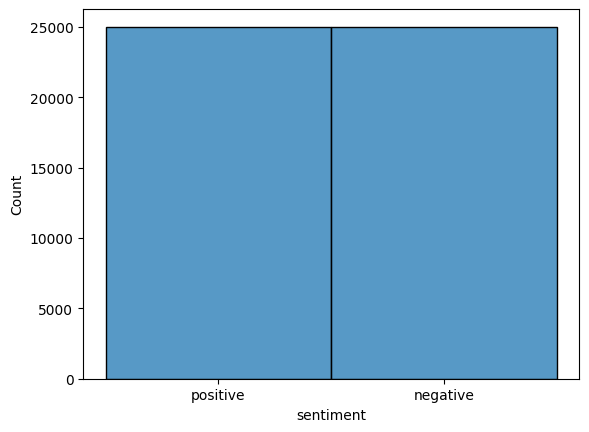

In [12]:
import seaborn as sns

sns.histplot(df['sentiment'])

In [14]:
df.head(15)

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
5,"Probably my all-time favorite movie, a story o...",positive
6,I sure would like to see a resurrection of a u...,positive
7,"This show was an amazing, fresh & innovative i...",negative
8,Encouraged by the positive comments about this...,negative
9,If you like original gut wrenching laughter yo...,positive


In [15]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [16]:
df['word_count'] = df['review'].apply(lambda x: len(x.split()))
df['char_count'] = df['review'].apply(lambda x: len(x))
df[['word_count', 'char_count']].describe()

,word_count,char_count
count,50000.000000,50000.000000
mean,231.156940,1309.431020
std,171.343997,989.728014
min,4.000000,32.000000
25%,126.000000,699.000000
50%,173.000000,970.000000
75%,280.000000,1590.250000
max,2470.000000,13704.000000


In [17]:
df[['word_count', 'char_count', 'sentiment']].groupby(by='sentiment').describe().T

sentiment             negative      positive
word_count count  25000.000000  25000.000000
           mean     229.464560    232.849320
           std      164.947795    177.497046
           min        4.000000     10.000000
           25%      128.000000    125.000000
           50%      174.000000    172.000000
           75%      278.000000    284.000000
           max     1522.000000   2470.000000
char_count count  25000.000000  25000.000000
           mean    1294.064360   1324.797680
           std      945.892669   1031.492627
           min       32.000000     65.000000
           25%      706.000000    691.000000
           50%      973.000000    968.000000
           75%     1567.250000   1614.000000
           max     8969.000000  13704.000000

<Axes: xlabel='sentiment', ylabel='word_count'>

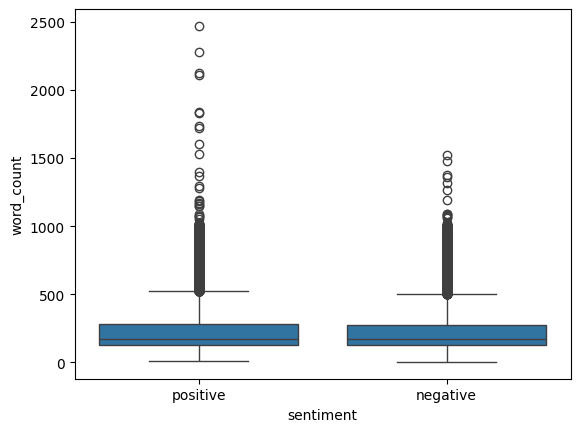

In [20]:
sns.boxplot(data=df, x='sentiment', y='word_count')

<Axes: xlabel='sentiment', ylabel='char_count'>

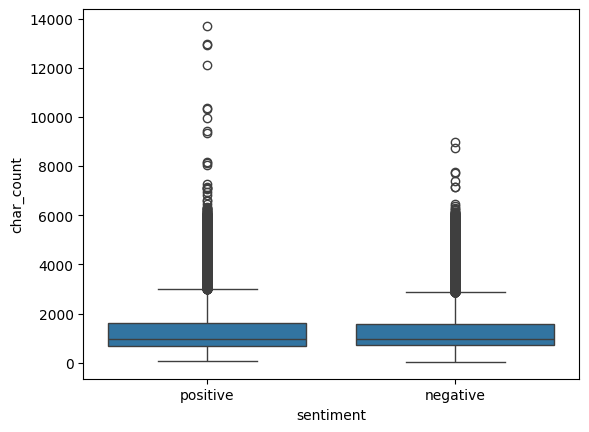

In [21]:
sns.boxplot(data=df, x='sentiment', y='char_count')

In [31]:
all_text = "".join(df['review'])

symbol_counts = {}

for char in all_text:
    symbol_counts[char] = symbol_counts.get(char, 0) + 1

print(symbol_counts)

{'O': 54998, 'n': 3321375, 'e': 6036511, ' ': 11507297, 'o': 3754514, 'f': 1085018, 't': 4565527, 'h': 2701649, 'r': 3003149, 'v': 617921, 'i': 3654084, 'w': 936183, 's': 3342252, 'a': 3979283, 'm': 1317735, 'd': 1715235, 'c': 1351529, 'g': 1016124, 'j': 74962, 'u': 1345564, '1': 35792, 'z': 40445, 'p': 824208, 'y': 1031725, "'": 263760, 'l': 2194831, 'b': 929635, 'k': 414662, '.': 650520, 'T': 220030, ',': 544818, 'x': 84005, '<': 202094, '/': 215720, '>': 202250, 'G': 47367, 'I': 264480, 'Z': 4490, 'M': 83700, 'S': 119546, 'P': 49662, 'E': 62149, 'C': 77492, 'A': 129582, 'L': 55859, 'F': 47474, 'N': 51707, '(': 69585, ')': 71268, 'W': 70424, 'q': 37098, '-': 132038, 'B': 89001, '"': 131858, '!': 49164, 'Y': 21969, ':': 19800, 'H': 79548, '2': 15978, 'R': 59387, '?': 32338, 'J': 41145, 'D': 76272, '&': 7714, 'K': 28837, '3': 11002, '0': 37357, '5': 10457, 'V': 29518, '7': 8277, '8': 8874, '9': 19392, '+': 642, 'U': 17488, '*': 13916, '6': 6209, '4': 8342, ';': 13375, 'Q': 2842, 'X': 1

In [36]:
!pip install beautifulsoup4 nltk wordcloud --quiet && echo 'beautifulsoup4' >> ../requirements.txt && echo 'nltk' >> ../requirements.txt && echo 'wordcloud' >> ../requirements.txt

In [41]:
import re
from bs4 import BeautifulSoup
from nltk.stem import PorterStemmer

ps = PorterStemmer()

def clean_text(text):
    soup = BeautifulSoup(text, "html.parser")
    text = soup.get_text()
    
    text = re.sub(r'\[[^]]*\]', '', text)
    text = re.sub(r'[^a-zA-z0-9\s]', '', text)
    
    tokens = text.lower().split()
    stemmed_tokens = [ps.stem(w) for w in tokens if w not in stop_words]
    
    return " ".join(stemmed_tokens)

In [43]:
from nltk.corpus import stopwords
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import nltk

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

sample_review = df['review'][0]
# print("Original:", sample_review[:100])
# print("Cleaned:", clean_text(sample_review)[:100])

df['cleaned_review'] = df['review'].apply(clean_text)

[nltk_data] Downloading package stopwords to /home/coffee/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


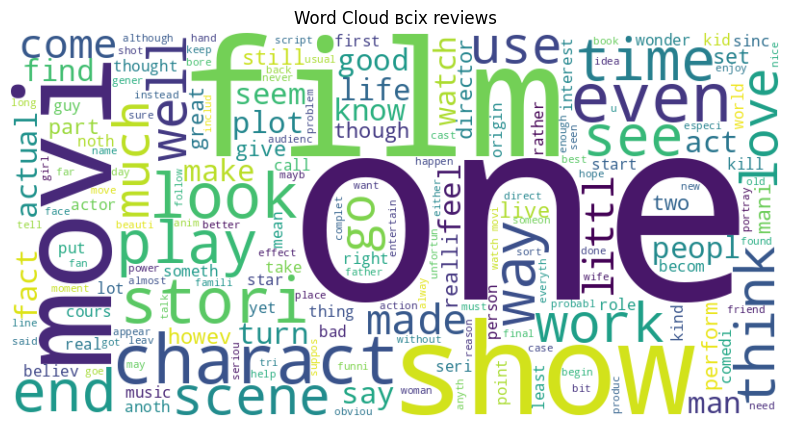

In [48]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

all_text = ' '.join(df['cleaned_review'].astype(str).tolist())

wordcloud = WordCloud(width=800, height=400, background_color='white', min_font_size=10).generate(all_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  
plt.title("Word Cloud всіх reviews")
plt.show()

In [55]:
positive_text = ' '.join(df[df['sentiment'] == 'positive']['cleaned_review'].astype(str).tolist())
negative_text = ' '.join(df[df['sentiment'] == 'negative']['cleaned_review'].astype(str).tolist())

wc_pos = WordCloud(width=1000, height=1000, background_color='white').generate(positive_text)
wc_neg = WordCloud(width=1000, height=1000, background_color='white', colormap='coolwarm').generate(negative_text)


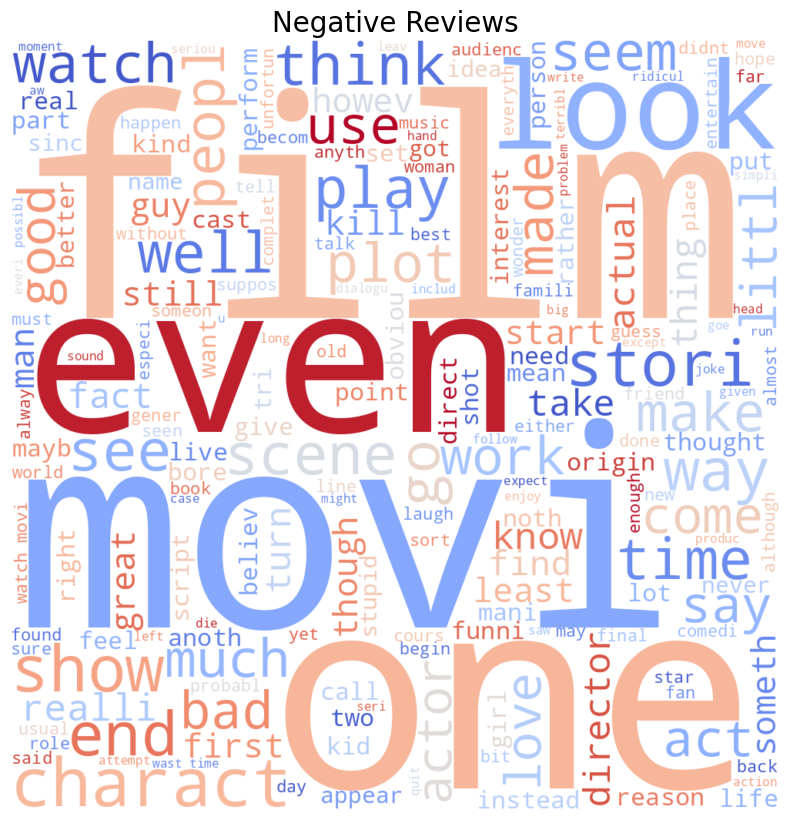

In [56]:
plt.figure(figsize=(10, 10))
plt.imshow(wc_neg, interpolation='bilinear')
plt.axis('off') 
plt.title('Negative Reviews', fontsize=20)
plt.show()

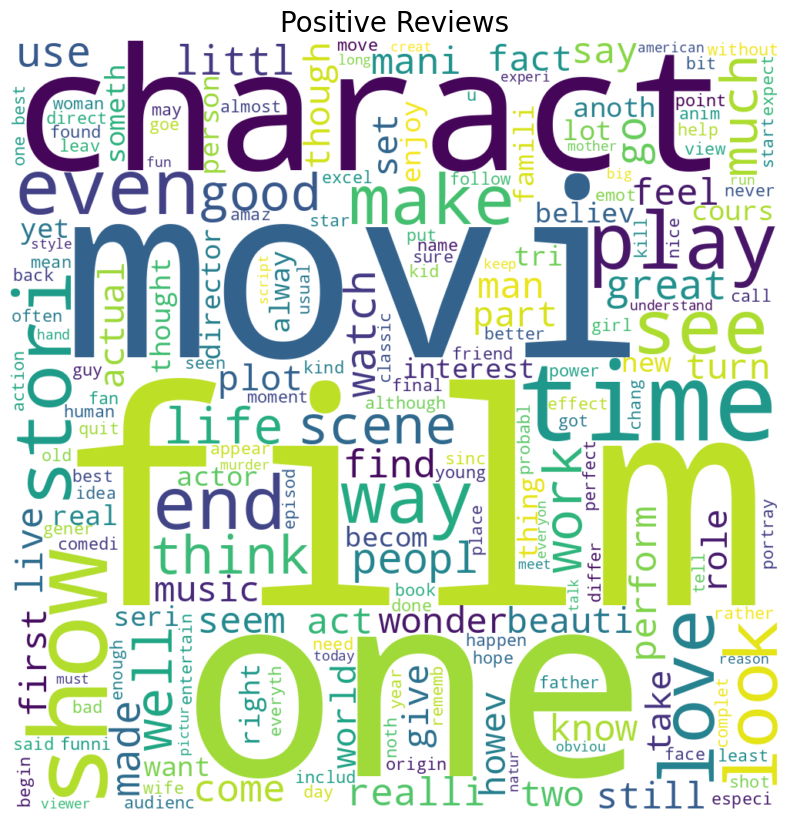

In [57]:
plt.figure(figsize=(10, 10))
plt.imshow(wc_pos, interpolation='bilinear')
plt.axis('off') 
plt.title('Positive Reviews', fontsize=20)
plt.show()

In [58]:
!pip install textblob --quiet && echo 'textblob' >> ../requirements.txt

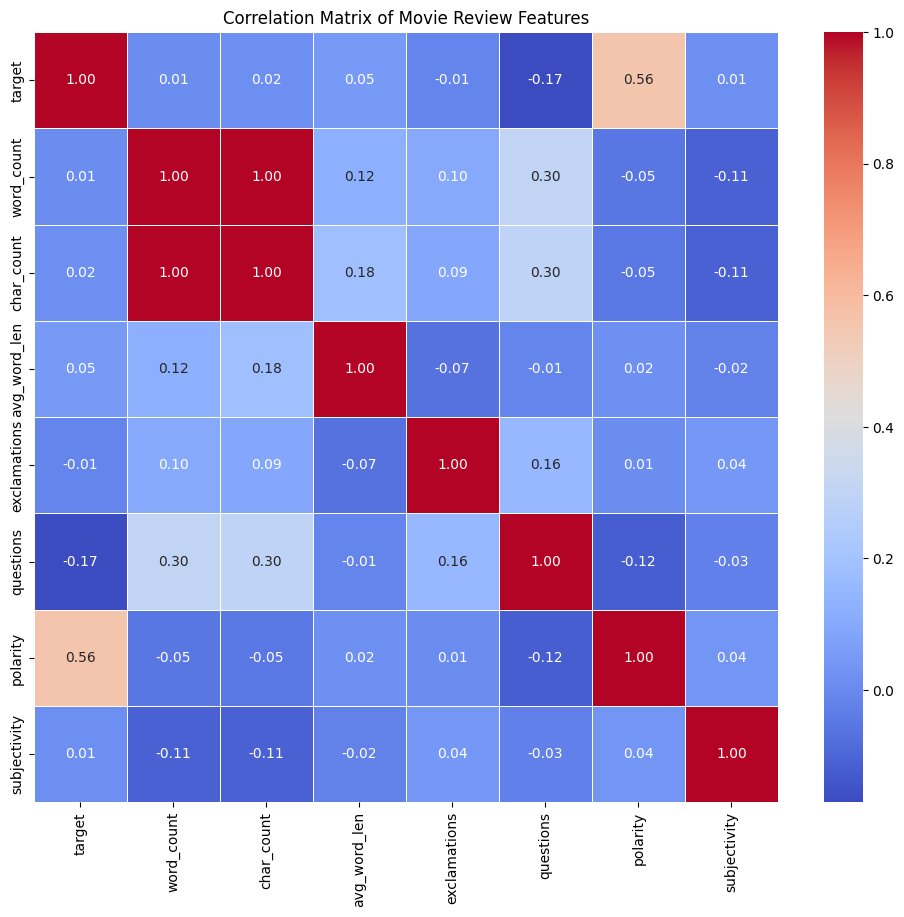

In [59]:
from textblob import TextBlob

df['target'] = df['sentiment'].apply(lambda x: 1 if x == 'positive' else 0)
df['avg_word_len'] = df['char_count'] / df['word_count']
df['exclamations'] = df['review'].apply(lambda x: x.count('!'))
df['questions'] = df['review'].apply(lambda x: x.count('?'))
df['polarity'] = df['review'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
df['subjectivity'] = df['review'].apply(lambda x: TextBlob(str(x)).sentiment.subjectivity)

features_to_corr = ['target', 'word_count', 'char_count', 'avg_word_len', 
                    'exclamations', 'questions', 'polarity', 'subjectivity']

plt.figure(figsize=(12, 10))
corr_matrix = df[features_to_corr].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Movie Review Features')
plt.show()

In [2]:
import pandas as pd

df = pd.read_csv("../data/processed/train.csv")

total_words = df['cleaned_review'].dropna().str.split().str.len().sum()

print(f"Загальна кількість слів у датасеті: {int(total_words)}")

Загальна кількість слів у датасеті: 4552669
